In [1]:
import pandas as pd

df = pd.read_csv('/content/customer_support_tickets.csv')

print(df.columns)

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns

In [3]:
nltk.download('punkt')

nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
df = pd.read_csv('/content/customer_support_tickets.csv')

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [5]:
df = df[
    [
        'Ticket Description',
        'Ticket Type',
        'Ticket Priority'
    ]
]

df.head()

,Ticket Description,Ticket Type,Ticket Priority
0,I'm having an issue with the {product_purchase...,Technical issue,Critical
1,I'm having an issue with the {product_purchase...,Technical issue,Critical
2,I'm facing a problem with my {product_purchase...,Technical issue,Low
3,I'm having an issue with the {product_purchase...,Billing inquiry,Low
4,I'm having an issue with the {product_purchase...,Billing inquiry,Low


In [6]:
df.dropna(inplace=True)

df.shape

(8469, 3)

In [8]:
import nltk

nltk.download('punkt')

nltk.download('punkt_tab')

nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
import re

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = word_tokenize(text)

    words = [
        word for word in words
        if word not in stop_words
    ]

    return ' '.join(words)

df['Cleaned_Text'] = df['Ticket Description'].apply(clean_text)

df[['Ticket Description','Cleaned_Text']].head()

,Ticket Description,Cleaned_Text
0,I'm having an issue with the {product_purchase...,im issue productpurchased please assist billin...
1,I'm having an issue with the {product_purchase...,im issue productpurchased please assist need c...
2,I'm facing a problem with my {product_purchase...,im facing problem productpurchased productpurc...
3,I'm having an issue with the {product_purchase...,im issue productpurchased please assist proble...
4,I'm having an issue with the {product_purchase...,im issue productpurchased please assist note s...


In [10]:
X = df['Cleaned_Text']

y = df['Ticket Type']

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(X)

print(X.shape)

(8469, 6903)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
model = MultinomialNB()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [13]:
accuracy = accuracy_score(
    y_test,
    predictions
)

precision = precision_score(
    y_test,
    predictions,
    average='weighted',
    zero_division=0
)

recall = recall_score(
    y_test,
    predictions,
    average='weighted',
    zero_division=0
)

print("Accuracy:", round(accuracy,2))

print("Precision:", round(precision,2))

print("Recall:", round(recall,2))

print(classification_report(
    y_test,
    predictions,
    zero_division=0
))

Accuracy: 0.19
Precision: 0.18
Recall: 0.19
                      precision    recall  f1-score   support

     Billing inquiry       0.15      0.04      0.07       357
Cancellation request       0.18      0.15      0.17       327
     Product inquiry       0.14      0.11      0.12       316
      Refund request       0.19      0.30      0.24       345
     Technical issue       0.21      0.32      0.26       349

            accuracy                           0.19      1694
           macro avg       0.18      0.19      0.17      1694
        weighted avg       0.18      0.19      0.17      1694



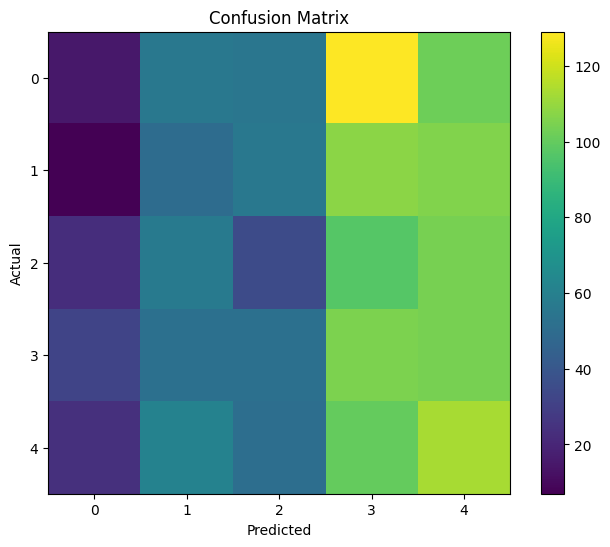

In [14]:
cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.title('Confusion Matrix')

plt.colorbar()

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

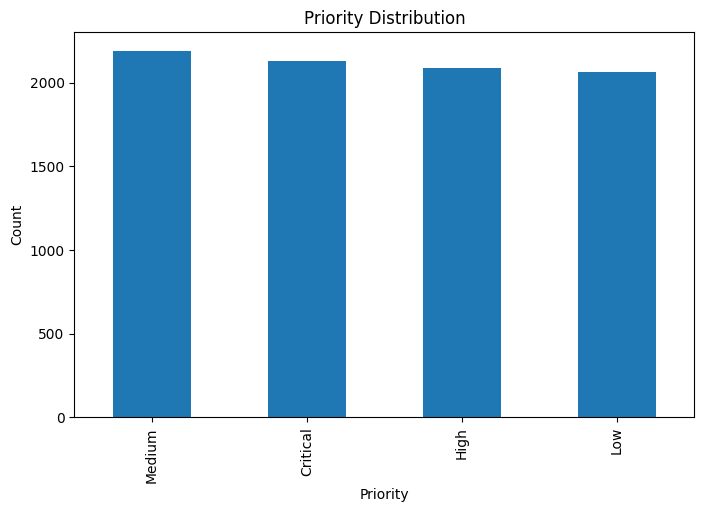

In [15]:
priority_count = df[
    'Ticket Priority'
].value_counts()

plt.figure(figsize=(8,5))

priority_count.plot(
    kind='bar'
)

plt.title(
    'Priority Distribution'
)

plt.xlabel('Priority')

plt.ylabel('Count')

plt.show()

## Business Insights

1. Automated ticket classification reduces manual work.

2. Priority prediction helps resolve urgent issues faster.

3. NLP improves support team efficiency.

4. Faster ticket resolution increases customer satisfaction.

5. Businesses can reduce ticket backlog.